In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [2]:
f = 1.420 #frequency in GHz
JyToK = 1.985 #conversion rate from Jansky to K

def rmFlag(flagInd, *args):
    flagInd.sort(reverse=True)
    newLists = []
    for j in args:
        for i in flagInd:
            del j[i]
        newLists.append(j)
    return newLists

def getInd(ind, *args):
    newLists = []
    for j in args:
        newList = []
        for i in ind:
            newList.append(j[i])
        newLists.append(newList)
    return newLists

def f1(el,a,b,tau):
    return a + b*tau/(np.sin(el*np.pi/180.0))

def f2(el,a,b,tau):
    return a*np.exp(b*tau/(np.sin(el*np.pi/180.0)))

def f3(el,a,tau):
    return a*np.exp(-1*tau/(np.sin(el*np.pi/180.0)))

#coefficients found from Perley & Butler for 3C48
a0 = 1.3253
a1 = -0.7553
a2 = -0.1914
a3 = 0.0498
T3C48 = JyToK * np.power(10,(a0 + a1*np.log10(f) + a2*np.power(np.log10(f),2) + a3*np.power(np.log10(f),3)))

In [3]:
# No need to run if sflux.csv already exists
# Note that this only works for a specific text format and is kind-of single purpose: improve if time allows

csvExists = True

if not csvExists:
    sftxt = open("./Results/sflux.txt", "r+")
    sflines = (sftxt.readlines())

    #sflux.txt needs both lines consolidated to one row

    c=" "
    sfrows = []

    for i in range(1,len(sflines),2):
        line1 = sflines[i].strip()
        line1 = c.join(line1.split())
        line2 = sflines[i+1].strip()
        line2 = c.join(line2.split())
        sflist = line1.split(c)
        sflist.extend(line2.split(c))
        for j in range(1,3):
            sflist[j] = int(sflist[j])
        for j in range(3,10):
            sflist[j] = float(sflist[j])
        sfrows.append(sflist)

    with open("./Results/sflux.csv", "w+") as sfcsv:
        csv_writer = csv.writer(sfcsv, delimiter=",")
        csv_writer.writerow(sflines[0].strip().split())
        for i in sfrows:
            csv_writer.writerow(i)

Calculated T of 3C48: 31.899K
AYY = 28.038
AXX = 27.628
Original Tcal for YY = 1.466K
Original Tcal for XX = 1.455K
Corrected Tcal for YY = 1.66767K
Corrected Tcal for XX = 1.67997K


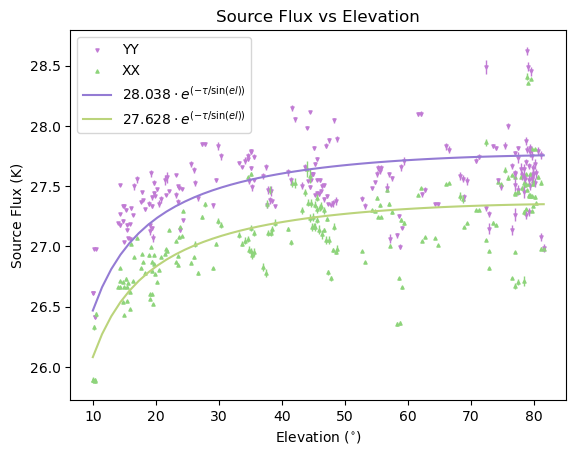

In [4]:
#Populate lists with previously calculated values
filepath = "./results/sflux.csv"
sfrows = []
sflux = []
stdSflux = []
meanTcal = []
az = []
el = []
ra = []
dec = []

with open(filepath, "r") as sfcsv:
    csv_reader = csv.reader(sfcsv)
    for row in csv_reader:
        try:
            sflux.append(float(row[3]))
            stdSflux.append(float(row[4]))
            meanTcal.append(float(row[5]))
            az.append(float(row[6]))
            el.append(float(row[7]))
            ra.append(float(row[8]))
            dec.append(float(row[9]))
            sfrows.append(row)
        except ValueError:
            pass

#Flag and exclude outliers
sfluxCutoff = 29
flag = []
for i in range(len(sfrows)):
    if sflux[i] > sfluxCutoff:
        flag.append(i)

sflux, stdSflux, meanTcal, az, el, ra, dec = rmFlag(flag, sflux, stdSflux, meanTcal, az, el, ra, dec)

#Separate by polarization
pol0 = np.arange(0,len(sflux),2)
pol1 = np.arange(1,len(sflux),2)

sflux0, stdSflux0, meanTcal0, az0, el0, ra0, dec0 = getInd(pol0, sflux, stdSflux, meanTcal, az, el, ra, dec)
tcal0 = np.mean(meanTcal0)

sflux1, stdSflux1, meanTcal1, az1, el1, ra1, dec1 = getInd(pol1, sflux, stdSflux, meanTcal, az, el, ra, dec)
tcal1 = np.mean(meanTcal1)

#Opacity calculations
tau = 0.01

# fig = plt.figure(figsize=(13,5))
fig = plt.figure()
# ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,1,1)
c1="#C17BD4"
c2="#8ED47B"
c3="#947BD4"
c4="#BBD47B"
c5="#7B8ED4"

# ax1.errorbar(az0,sflux0,yerr=stdSflux0,c=c1,fmt="None",elinewidth=1)
# ax1.scatter(az0,sflux0,c=c1,s=5,marker="v")
# ax1.errorbar(az1,sflux1,yerr=stdSflux1,c=c2,fmt="None",elinewidth=1)
# ax1.scatter(az1,sflux1,c=c2,s=5,marker="^")
# ax1.set_title("Source Flux vs Azimuth")
# ax1.set_xlabel("Azimuth ($^{\circ}$)")
# ax1.set_ylabel("Source Flux (K)")
# ax1.legend(["YY", "XX"],loc=2)

ax2.errorbar(el0,sflux0,yerr=stdSflux0,c=c1,fmt="None",elinewidth=1)
ax2.scatter(el0,sflux0,c=c1,s=5,marker="v")
ax2.errorbar(el1,sflux1,yerr=stdSflux1,c=c2,fmt="None",elinewidth=1)
ax2.scatter(el1,sflux1,c=c2,s=5,marker="^")
ax2.set_title("Source Flux vs Elevation")
ax2.set_xlabel("Elevation ($^{\circ}$)")
ax2.set_ylabel("Source Flux (K)")

xrange = np.linspace(np.min(el), np.max(el))
e = 1e-5

# popt,pcov = curve_fit(f2,el,sflux,bounds=((0,-np.inf,0.01-e),(np.inf,0,0.01+e)))
# ax2.plot(xrange,f2(xrange,popt[0],popt[1],popt[2]),c=c5)
# a1 = popt[0]
# b1 = popt[1]
# l1 = "$" + str(round(a1,2)) + "\cdot e^{(" + str(round(b1,2)) + "*\\tau/\sin(el))}$"

popt,pcov = curve_fit(f3,el0,sflux0,bounds=((0,0.01-e),(np.inf,0.01+e)))
ax2.plot(xrange,f3(xrange,popt[0],popt[1]),c=c3)
a2 = popt[0]
l2 = "$" + str(round(a2,3)) + "\cdot e^{(-\\tau/\sin(el))}$"

popt,pcov = curve_fit(f3,el1,sflux1,bounds=((0,0.01-e),(np.inf,0.01+e)))
ax2.plot(xrange,f3(xrange,popt[0],popt[1]),c=c4)
a3 = popt[0]
l3 = "$" + str(round(a3,3)) + "\cdot e^{(-\\tau/\sin(el))}$"

ax2.legend(["YY", "XX", l2, l3], loc=2)

plt.savefig("./figures/sfluxVsEl.png",dpi=300)

# factor * t / sin(el)
# or was it factor * exp(t/sin(el)) ?

# 1.98 5 K per jansky

tcalpol0 = tcal0 * T3C48 / a2
tcalpol1 = tcal1 * T3C48 / a3

print("Calculated T of 3C48: " + str(round(T3C48,3)) + "K")
print("AYY = " + str(round(a2,3)))
print("AXX = " + str(round(a3,3)))
print("Original Tcal for YY = " + str(round(tcal0,3)) + "K")
print("Original Tcal for XX = " + str(round(tcal1,3)) + "K")
print("Corrected Tcal for YY = " + str(round(tcalpol0,5)) + "K")
print("Corrected Tcal for XX = " + str(round(tcalpol1,5)) + "K")